# WebUI Balanced 7K Dataset - Exploratory Data Analysis

**Objective**: Assess dataset quality, balance, and suitability for object detection model training.

**Dataset**: 7,009 web page samples × 6 device configurations = 42,054 annotated screenshots

## Setup and Imports

In [2]:
import json
import gzip
from pathlib import Path
from collections import defaultdict, Counter
from typing import Dict, List, Tuple
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# Configure plotting
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Dataset paths
DATASET_ROOT = Path(r'C:\WebUIDetection\balanced_7k')
INDEX_FILE = Path(r'C:\WebUIDetection\webui-balanced-7k-20260208T053018Z-1-003\webui-balanced-7k\balanced_7k.json')

# Device configurations
DEVICES = {
    'desktop': ['default_1280-720', 'default_1366-768', 'default_1536-864', 'default_1920-1080'],
    'tablet': ['iPad-Pro'],
    'mobile': ['iPhone-13 Pro']
}
ALL_CONFIGS = DEVICES['desktop'] + DEVICES['tablet'] + DEVICES['mobile']

print(f'Dataset Root: {DATASET_ROOT}')
print(f'Index File: {INDEX_FILE}')
print(f'Configurations: {len(ALL_CONFIGS)}')

Dataset Root: C:\WebUIDetection\balanced_7k
Index File: C:\WebUIDetection\webui-balanced-7k-20260208T053018Z-1-003\webui-balanced-7k\balanced_7k.json
Configurations: 6


## 1. Dataset Integrity & Health Check

In [3]:
# Load sample IDs
with open(INDEX_FILE, 'r') as f:
    sample_ids = json.load(f)

print(f'Total samples in index: {len(sample_ids)}')
print(f'First 5 samples: {sample_ids[:5]}')
print(f'Last 5 samples: {sample_ids[-5:]}')

Total samples in index: 7000
First 5 samples: ['1656507072588', '1656367243412', '1655989741425', '1656065034741', '1656140658736']
Last 5 samples: ['1658374002939', '1657186973318', '1657462217843', '1659785628894', '1658566632040']


In [4]:
def check_sample_integrity(sample_id: str, dataset_root: Path) -> Dict:
    """
    Check if a sample has all required files for all device configurations.
    
    Returns:
        Dict with status, missing_configs, missing_files
    """
    sample_dir = dataset_root / sample_id
    
    if not sample_dir.exists():
        return {'status': 'missing_directory', 'missing_configs': ALL_CONFIGS, 'missing_files': []}
    
    required_files = [
        'axtree.json.gz', 'bb.json.gz', 'box.json.gz', 'class.json.gz',
        'html.html', 'links.json', 'screenshot-full.webp', 'screenshot.webp',
        'style.json.gz', 'url.txt', 'viewport.json.gz'
    ]
    
    missing_configs = []
    missing_files = []
    
    for config in ALL_CONFIGS:
        config_has_all = True
        for file_suffix in required_files:
            file_path = sample_dir / f'{config}-{file_suffix}'
            if not file_path.exists():
                missing_files.append(f'{config}-{file_suffix}')
                config_has_all = False
        
        if not config_has_all:
            missing_configs.append(config)
    
    status = 'complete' if len(missing_configs) == 0 else 'incomplete'
    return {
        'status': status,
        'missing_configs': missing_configs,
        'missing_files': missing_files
    }

# Quick check on first 100 samples
print('Running quick integrity check on first 100 samples...')
integrity_results = []
for sample_id in tqdm(sample_ids[:100], desc='Checking samples'):
    result = check_sample_integrity(sample_id, DATASET_ROOT)
    integrity_results.append({'sample_id': sample_id, **result})

integrity_df = pd.DataFrame(integrity_results)
print(f"\nIntegrity Check Summary (first 100 samples):")
print(integrity_df['status'].value_counts())

Running quick integrity check on first 100 samples...


Checking samples: 100%|██████████| 100/100 [00:00<00:00, 156.08it/s]


Integrity Check Summary (first 100 samples):
status
complete    100
Name: count, dtype: int64


In [5]:
# Full dataset integrity check
print('Running full dataset integrity check...')
full_integrity_results = []

for sample_id in tqdm(sample_ids, desc='Checking all samples'):
    result = check_sample_integrity(sample_id, DATASET_ROOT)
    full_integrity_results.append({'sample_id': sample_id, **result})

full_integrity_df = pd.DataFrame(full_integrity_results)

# Summary statistics
status_counts = full_integrity_df['status'].value_counts()
print(f"\n{'='*60}")
print("DATASET INTEGRITY SUMMARY")
print(f"{'='*60}")
print(f"Total samples: {len(full_integrity_df)}")
print(f"Complete samples: {status_counts.get('complete', 0)} ({status_counts.get('complete', 0)/len(full_integrity_df)*100:.2f}%)")
print(f"Incomplete samples: {status_counts.get('incomplete', 0)}")
print(f"Missing directories: {status_counts.get('missing_directory', 0)}")

if len(full_integrity_df[full_integrity_df['status'] != 'complete']) > 0:
    print(f"\nWARNING: {len(full_integrity_df[full_integrity_df['status'] != 'complete'])} problematic samples detected")
    problematic = full_integrity_df[full_integrity_df['status'] != 'complete'].head(10)
    print("\nFirst 10 problematic samples:")
    print(problematic[['sample_id', 'status', 'missing_configs']])
else:
    print("\nAll samples are complete and valid.")

Running full dataset integrity check...


Checking all samples: 100%|██████████| 7000/7000 [00:40<00:00, 173.29it/s]


DATASET INTEGRITY SUMMARY
Total samples: 7000
Complete samples: 6996 (99.94%)
Incomplete samples: 4
Missing directories: 0


First 10 problematic samples:
          sample_id      status                              missing_configs
4706  1656081358661  incomplete  [default_1280-720, iPad-Pro, iPhone-13 Pro]
4819  1656265957879  incomplete                                   [iPad-Pro]
5327  1656174897093  incomplete                                   [iPad-Pro]
5356  1656302012565  incomplete                    [iPad-Pro, iPhone-13 Pro]


## 2. Device / View Distribution Analysis

In [6]:
# Use only complete samples for analysis
valid_samples = full_integrity_df[full_integrity_df['status'] == 'complete']['sample_id'].tolist()
print(f'Valid samples for analysis: {len(valid_samples)}')

# Count screenshots per device type
device_counts = {
    'Desktop': len(valid_samples) * len(DEVICES['desktop']),
    'Tablet': len(valid_samples) * len(DEVICES['tablet']),
    'Mobile': len(valid_samples) * len(DEVICES['mobile'])
}

# Detailed config counts
config_counts = {config: len(valid_samples) for config in ALL_CONFIGS}

print(f"\nDevice Type Distribution:")
for device_type, count in device_counts.items():
    print(f"  {device_type}: {count:,} screenshots")

print(f"\nTotal screenshots: {sum(device_counts.values()):,}")

Valid samples for analysis: 6996

Device Type Distribution:
  Desktop: 27,984 screenshots
  Tablet: 6,996 screenshots
  Mobile: 6,996 screenshots

Total screenshots: 41,976


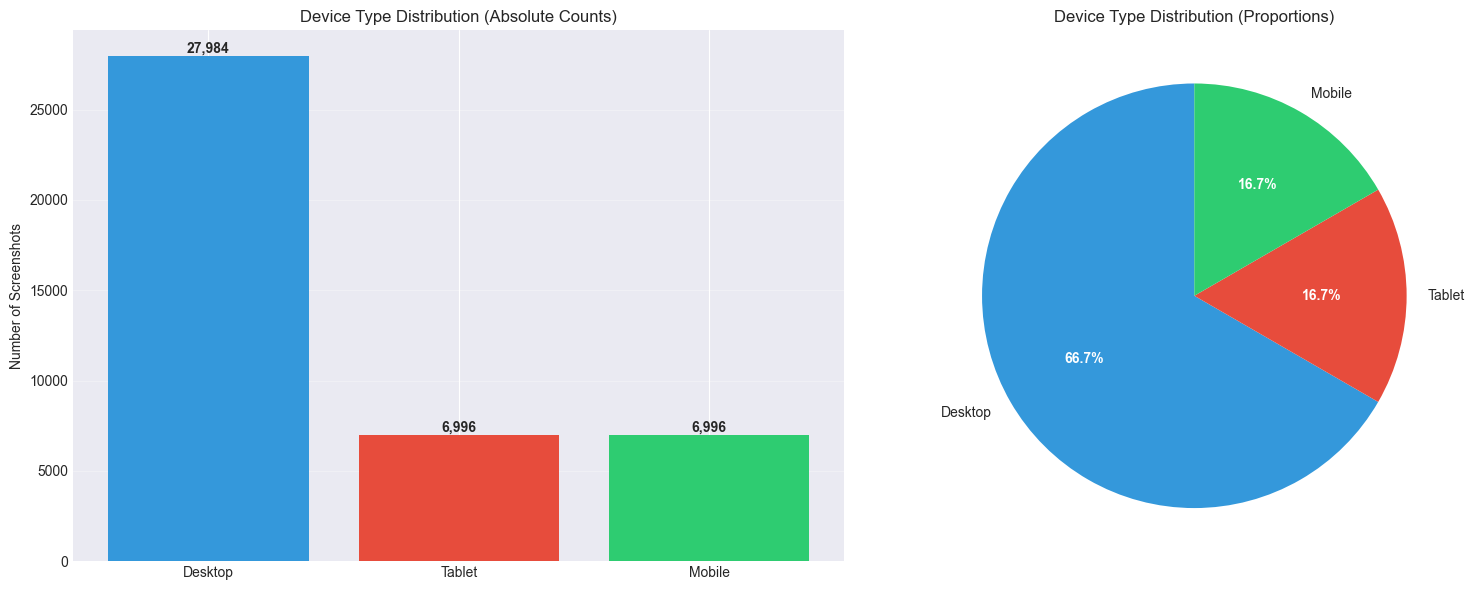


DEVICE BALANCE ASSESSMENT
Desktop: 66.7% (4 configurations)
Tablet: 16.7% (1 configuration)
Mobile: 16.7% (1 configuration)

Conclusion: Dataset is heavily skewed toward desktop viewports.
This is not 'balanced' across device types, but balanced within desktop resolutions.


In [7]:
# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart - absolute counts
device_types = list(device_counts.keys())
counts = list(device_counts.values())
ax1 = axes[0]
bars = ax1.bar(device_types, counts, color=['#3498db', '#e74c3c', '#2ecc71'])
ax1.set_ylabel('Number of Screenshots')
ax1.set_title('Device Type Distribution (Absolute Counts)')
ax1.grid(axis='y', alpha=0.3)
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height):,}',
            ha='center', va='bottom', fontweight='bold')

# Pie chart - proportions
ax2 = axes[1]
colors = ['#3498db', '#e74c3c', '#2ecc71']
wedges, texts, autotexts = ax2.pie(counts, labels=device_types, autopct='%1.1f%%',
                                     colors=colors, startangle=90)
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
ax2.set_title('Device Type Distribution (Proportions)')

plt.tight_layout()
plt.savefig('device_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*60)
print("DEVICE BALANCE ASSESSMENT")
print("="*60)
desktop_pct = device_counts['Desktop'] / sum(device_counts.values()) * 100
print(f"Desktop: {desktop_pct:.1f}% (4 configurations)")
print(f"Tablet: {device_counts['Tablet'] / sum(device_counts.values()) * 100:.1f}% (1 configuration)")
print(f"Mobile: {device_counts['Mobile'] / sum(device_counts.values()) * 100:.1f}% (1 configuration)")
print(f"\nConclusion: Dataset is heavily skewed toward desktop viewports.")
print(f"This is not 'balanced' across device types, but balanced within desktop resolutions.")

## 3. UI Element Class Distribution

In [15]:
def load_classes_from_sample(sample_id: str, config: str) -> List[str]:
    """Load class labels (accessibility roles) from axtree.json.gz file."""
    axtree_file = DATASET_ROOT / sample_id / f'{config}-axtree.json.gz'
    try:
        with gzip.open(axtree_file, 'rt') as f:
            axtree = json.load(f)
        
        # Extract roles from accessibility tree
        # Map backendDOMNodeId to role value
        roles = []
        if 'nodes' in axtree:
            for node in axtree['nodes']:
                role_info = node.get('role', {})
                role_value = role_info.get('value', 'unknown')
                roles.append(role_value)
        
        return roles
    except Exception as e:
        return []

# Sample a subset first for speed (then full scan)
print('Extracting class labels from samples...')
sample_subset = valid_samples[:500]  # Sample 500 for quick analysis

class_counter_subset = Counter()
class_per_device_subset = {device_type: Counter() for device_type in ['Desktop', 'Tablet', 'Mobile']}

for sample_id in tqdm(sample_subset, desc='Processing subset'):
    for config in ALL_CONFIGS:
        classes = load_classes_from_sample(sample_id, config)
        class_counter_subset.update(classes)
        
        # Categorize by device type
        if config in DEVICES['desktop']:
            class_per_device_subset['Desktop'].update(classes)
        elif config in DEVICES['tablet']:
            class_per_device_subset['Tablet'].update(classes)
        elif config in DEVICES['mobile']:
            class_per_device_subset['Mobile'].update(classes)

print(f'\nUnique classes found (subset): {len(class_counter_subset)}')
print(f'Total UI elements (subset): {sum(class_counter_subset.values()):,}')
print(f'Class IDs: {sorted(class_counter_subset.keys())}')

Extracting class labels from samples...


Processing subset: 100%|██████████| 500/500 [00:35<00:00, 13.93it/s]


Unique classes found (subset): 86
Total UI elements (subset): 580,350
Class IDs: ['Abbr', 'Canvas', 'DescriptionList', 'DescriptionListDetail', 'DescriptionListTerm', 'Details', 'DisclosureTriangle', 'EmbeddedObject', 'Figcaption', 'FooterAsNonLandmark', 'HeaderAsNonLandmark', 'Iframe', 'IframePresentational', 'LabelText', 'LayoutTable', 'LayoutTableCell', 'LayoutTableRow', 'Legend', 'LineBreak', 'ListMarker', 'MenuListPopup', 'PluginObject', 'Pre', 'RootWebArea', 'Section', 'StaticText', 'SvgRoot', 'Video', 'alert', 'alertdialog', 'application', 'article', 'banner', 'blockquote', 'button', 'caption', 'checkbox', 'columnheader', 'combobox', 'complementary', 'contentinfo', 'dialog', 'document', 'emphasis', 'figure', 'form', 'generic', 'gridcell', 'group', 'heading', 'img', 'insertion', 'link', 'list', 'listbox', 'listitem', 'main', 'menu', 'menubar', 'menuitem', 'navigation', 'none', 'option', 'paragraph', 'progressbar', 'radio', 'region', 'row', 'rowheader', 'search', 'searchbox', 'se

**Note**: The dataset uses accessibility roles (from `axtree.json.gz`) as element types/classes, not numeric IDs. Roles include: button, link, text, image, etc.

In [16]:
# Full dataset class extraction
print('Extracting classes from full dataset...')
class_counter_full = Counter()
class_per_device_full = {device_type: Counter() for device_type in ['Desktop', 'Tablet', 'Mobile']}

sample_count = 0
error_count = 0

for sample_id in tqdm(valid_samples, desc='Processing all samples'):
    for config in ALL_CONFIGS:
        classes = load_classes_from_sample(sample_id, config)
        if len(classes) > 0:
            sample_count += 1
        else:
            error_count += 1
        class_counter_full.update(classes)
        
        if config in DEVICES['desktop']:
            class_per_device_full['Desktop'].update(classes)
        elif config in DEVICES['tablet']:
            class_per_device_full['Tablet'].update(classes)
        elif config in DEVICES['mobile']:
            class_per_device_full['Mobile'].update(classes)

print(f"\nProcessed {sample_count} samples with classes, {error_count} samples returned empty")

# Create summary DataFrame
if len(class_counter_full) == 0:
    print("\nERROR: No classes were extracted from the dataset!")
    print("This might indicate issues with the class.json.gz files.")
    # Create empty DataFrame to prevent further errors
    class_df = pd.DataFrame(columns=['class_id', 'count', 'percentage'])
else:
    class_df = pd.DataFrame([
        {
            'class_id': cls,
            'count': count,
            'percentage': count / sum(class_counter_full.values()) * 100
        }
        for cls, count in class_counter_full.items()
    ])
    if len(class_df) > 0:
        class_df = class_df.sort_values('count', ascending=False)

print(f"\n{'='*60}")
print("CLASS DISTRIBUTION SUMMARY")
print(f"{'='*60}")
print(f"Total unique classes: {len(class_df)}")
print(f"Total UI elements: {sum(class_counter_full.values()):,}")
if len(class_df) > 0:
    print(f"\nClass frequency table:")
    print(class_df.to_string(index=False))
else:
    print("\nNo class data available.")

Extracting classes from full dataset...


Processing all samples: 100%|██████████| 6996/6996 [07:23<00:00, 15.79it/s]


Processed 41976 samples with classes, 0 samples returned empty

CLASS DISTRIBUTION SUMMARY
Total unique classes: 100
Total UI elements: 5,167,159

Class frequency table:
             class_id   count  percentage
                 none 1584584   30.666446
           StaticText 1314900   25.447253
                 link  559099   10.820240
              generic  351116    6.795146
             listitem  308426    5.968967
            paragraph  225218    4.358643
              heading  154011    2.980574
            LineBreak  102261    1.979057
                  img   78403    1.517333
           ListMarker   64758    1.253261
                 list   62488    1.209330
          RootWebArea   41976    0.812361
             gridcell   37891    0.733304
              Section   26378    0.510493
             menuitem   25578    0.495011
              article   16093    0.311448
            separator   15650    0.302874
                  row   15303    0.296159
           navigation   15123  

In [17]:
# Identify imbalance
most_common = class_df.iloc[0]
least_common = class_df.iloc[-1]
imbalance_ratio = most_common['count'] / least_common['count']

print(f"\n{'='*60}")
print("CLASS IMBALANCE ANALYSIS")
print(f"{'='*60}")
print(f"Most common class: {most_common['class_id']} ({most_common['count']:,} instances, {most_common['percentage']:.2f}%)")
print(f"Least common class: {least_common['class_id']} ({least_common['count']:,} instances, {least_common['percentage']:.2f}%)")
print(f"Imbalance ratio: {imbalance_ratio:.2f}x")

# Identify rare classes (< 1%)
rare_classes = class_df[class_df['percentage'] < 1.0]
print(f"\nRare classes (< 1%): {len(rare_classes)}")
if len(rare_classes) > 0:
    print(rare_classes[['class_id', 'count', 'percentage']].to_string(index=False))

# Dominant classes (> 10%)
dominant_classes = class_df[class_df['percentage'] > 10.0]
print(f"\nDominant classes (> 10%): {len(dominant_classes)}")
if len(dominant_classes) > 0:
    print(dominant_classes[['class_id', 'count', 'percentage']].to_string(index=False))


CLASS IMBALANCE ANALYSIS
Most common class: none (1,584,584 instances, 30.67%)
Least common class: toolbar (2 instances, 0.00%)
Imbalance ratio: 792292.00x

Rare classes (< 1%): 89
             class_id  count  percentage
          RootWebArea  41976    0.812361
             gridcell  37891    0.733304
              Section  26378    0.510493
             menuitem  25578    0.495011
              article  16093    0.311448
            separator  15650    0.302874
                  row  15303    0.296159
           navigation  15123    0.292675
      LayoutTableCell  12669    0.245183
          contentinfo  12641    0.244641
               banner  12400    0.239977
               button  11949    0.231249
                 time  10659    0.206284
                 main   9316    0.180292
          LayoutTable   8789    0.170093
       LayoutTableRow   8455    0.163630
  HeaderAsNonLandmark   7847    0.151863
DescriptionListDetail   6688    0.129433
               figure   5659    0.10951

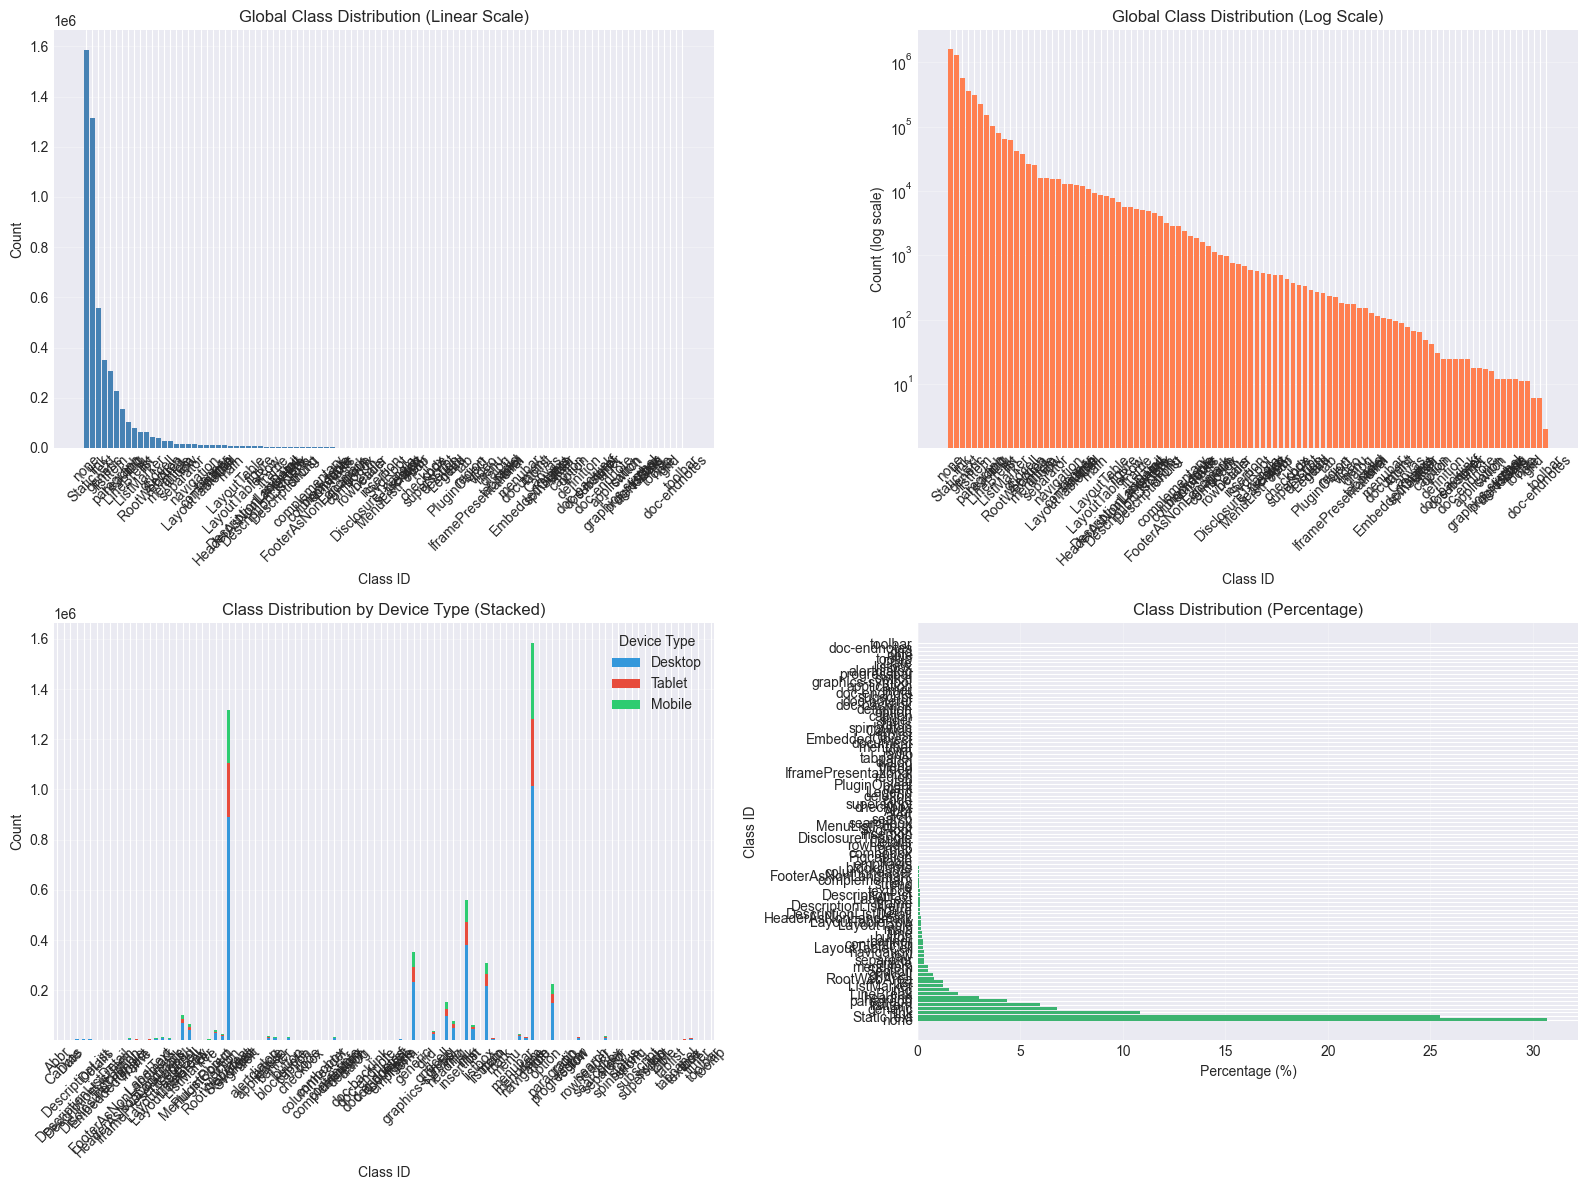

In [18]:
# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Bar chart - linear scale
ax1 = axes[0, 0]
ax1.bar(class_df['class_id'].astype(str), class_df['count'], color='steelblue')
ax1.set_xlabel('Class ID')
ax1.set_ylabel('Count')
ax1.set_title('Global Class Distribution (Linear Scale)')
ax1.grid(axis='y', alpha=0.3)
ax1.tick_params(axis='x', rotation=45)

# 2. Bar chart - log scale
ax2 = axes[0, 1]
ax2.bar(class_df['class_id'].astype(str), class_df['count'], color='coral')
ax2.set_xlabel('Class ID')
ax2.set_ylabel('Count (log scale)')
ax2.set_title('Global Class Distribution (Log Scale)')
ax2.set_yscale('log')
ax2.grid(axis='y', alpha=0.3)
ax2.tick_params(axis='x', rotation=45)

# 3. Stacked bar - class vs device type
ax3 = axes[1, 0]
device_class_data = pd.DataFrame({
    'Desktop': [class_per_device_full['Desktop'][cls] for cls in sorted(class_counter_full.keys())],
    'Tablet': [class_per_device_full['Tablet'][cls] for cls in sorted(class_counter_full.keys())],
    'Mobile': [class_per_device_full['Mobile'][cls] for cls in sorted(class_counter_full.keys())]
}, index=[str(cls) for cls in sorted(class_counter_full.keys())])

device_class_data.plot(kind='bar', stacked=True, ax=ax3, color=['#3498db', '#e74c3c', '#2ecc71'])
ax3.set_xlabel('Class ID')
ax3.set_ylabel('Count')
ax3.set_title('Class Distribution by Device Type (Stacked)')
ax3.legend(title='Device Type')
ax3.grid(axis='y', alpha=0.3)
ax3.tick_params(axis='x', rotation=45)

# 4. Percentage distribution
ax4 = axes[1, 1]
ax4.barh(class_df['class_id'].astype(str), class_df['percentage'], color='mediumseagreen')
ax4.set_xlabel('Percentage (%)')
ax4.set_ylabel('Class ID')
ax4.set_title('Class Distribution (Percentage)')
ax4.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

## 4. Bounding Box Geometry Analysis

In [20]:
def load_bounding_boxes(sample_id: str, config: str) -> Dict:
    """Load bounding boxes from bb.json.gz file."""
    bb_file = DATASET_ROOT / sample_id / f'{config}-bb.json.gz'
    try:
        with gzip.open(bb_file, 'rt') as f:
            bboxes = json.load(f)
        return bboxes
    except Exception:
        return {}

def analyze_bbox_geometry(bboxes: Dict, classes: List[str]) -> List[Dict]:
    """
    Analyze geometric properties of bounding boxes.
    
    Returns list of dicts with: width, height, area, aspect_ratio, class_id
    """
    geometries = []
    
    for element_id, bbox in bboxes.items():
        # Skip None or invalid bbox entries
        if bbox is None or not isinstance(bbox, dict):
            continue
        
        width = bbox.get('width', 0)
        height = bbox.get('height', 0)
        area = width * height
        aspect_ratio = width / height if height > 0 else 0
        
        # Match with class if available
        # Note: element_id might not directly map to classes array index
        # For now, skip class assignment in geometry analysis
        class_id = None
        
        geometries.append({
            'width': width,
            'height': height,
            'area': area,
            'aspect_ratio': aspect_ratio,
            'class_id': class_id
        })
    
    return geometries

# Sample analysis
print('Analyzing bounding box geometry...')
sample_for_geometry = valid_samples[:1000]  # Use 1000 samples

all_geometries = []

for sample_id in tqdm(sample_for_geometry, desc='Analyzing geometry'):
    for config in ALL_CONFIGS:
        bboxes = load_bounding_boxes(sample_id, config)
        classes = load_classes_from_sample(sample_id, config)
        geometries = analyze_bbox_geometry(bboxes, classes)
        all_geometries.extend(geometries)

geometry_df = pd.DataFrame(all_geometries)
geometry_df = geometry_df[geometry_df['area'] > 0]  # Remove invalid boxes

print(f"\nTotal bounding boxes analyzed: {len(geometry_df):,}")
print(f"\nGeometry statistics:")
print(geometry_df[['width', 'height', 'area', 'aspect_ratio']].describe())

Analyzing bounding box geometry...


Analyzing geometry: 100%|██████████| 1000/1000 [01:27<00:00, 11.46it/s]



Total bounding boxes analyzed: 843,154

Geometry statistics:
              width        height          area   aspect_ratio
count  8.431540e+05  8.431540e+05  8.431540e+05  843154.000000
mean   3.814665e+02  1.720351e+02  5.034186e+07       9.563221
std    7.482706e+03  6.742227e+03  1.882259e+10      49.674556
min    1.562500e-01  9.375000e-02  2.441406e-02       0.000195
25%    8.000000e+01  1.900000e+01  1.748000e+03       1.782493
50%    2.108828e+02  3.000000e+01  6.435000e+03       4.500000
75%    4.607969e+02  6.678125e+01  3.141600e+04       9.553353
max    2.800000e+06  2.520000e+06  7.056000e+12   17543.666667


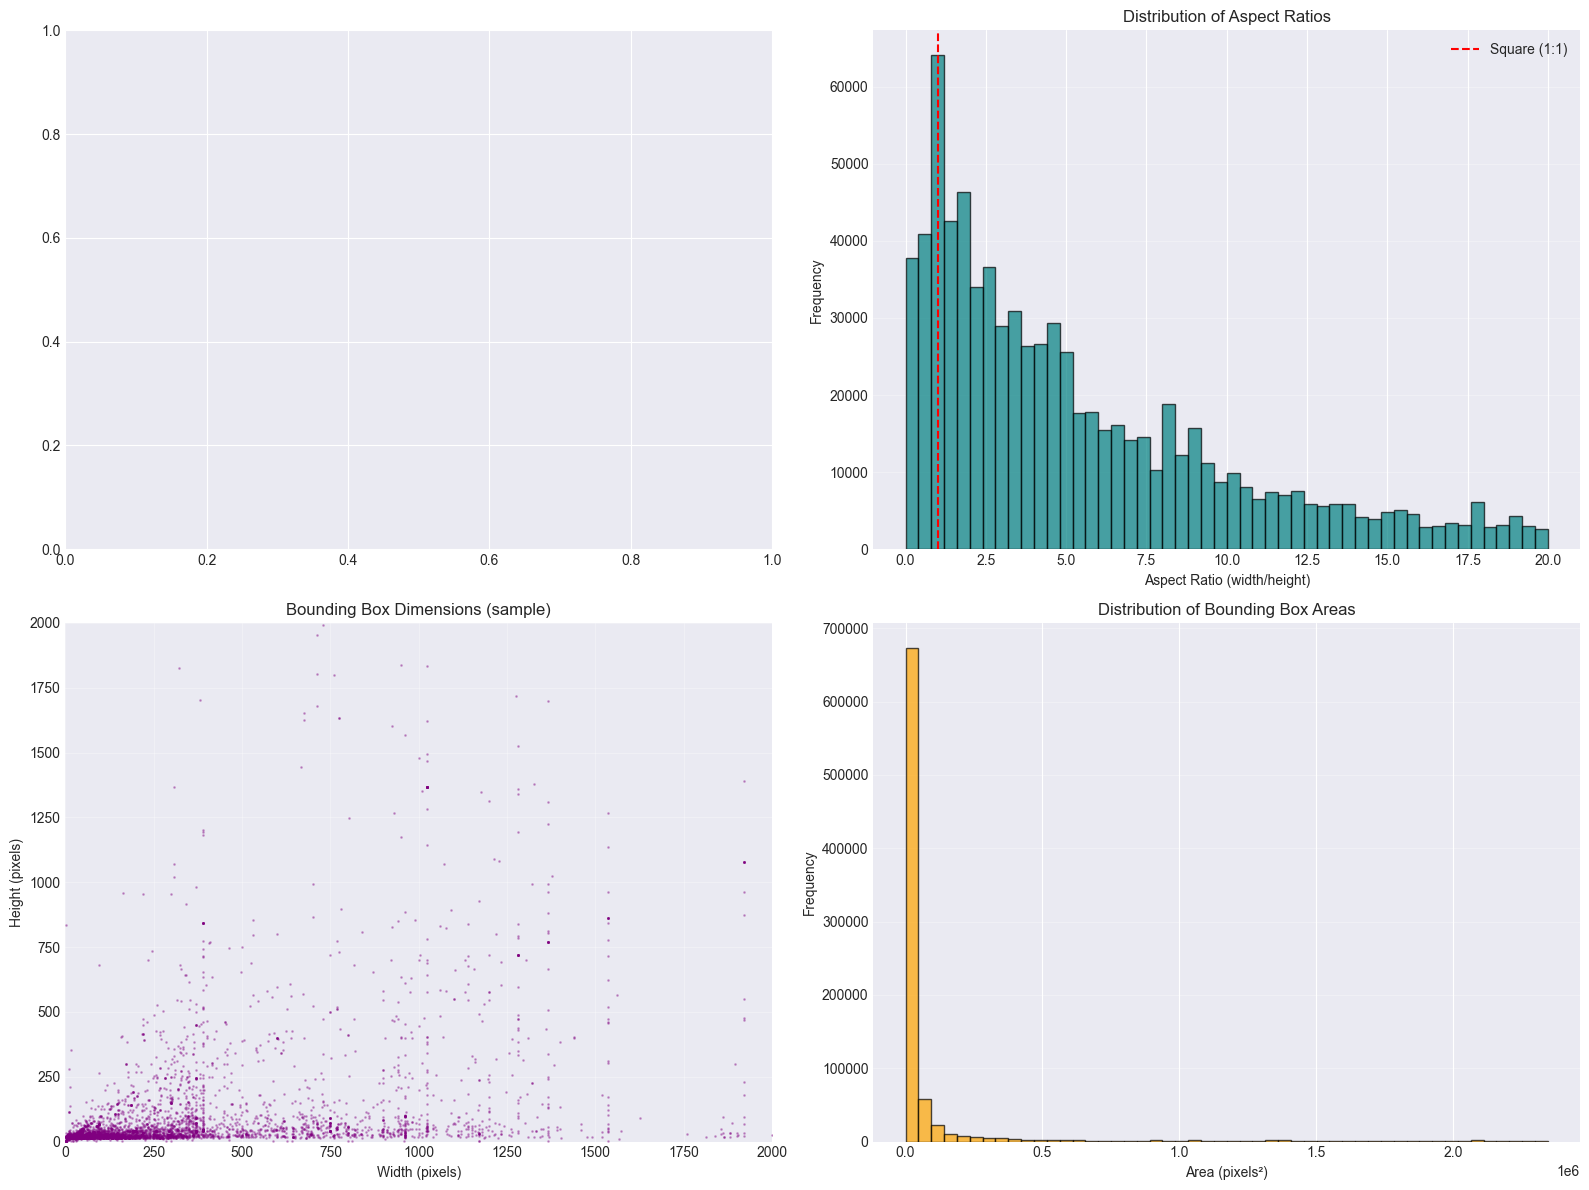


GEOMETRY INSIGHTS
Median area: 6435 pixels²
Median aspect ratio: 4.50
Small elements (area < 1000 px²): 16.1%
Large elements (area > 50000 px²): 19.4%


In [21]:
# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Box plot - area per class
ax1 = axes[0, 0]
valid_classes = geometry_df[geometry_df['class_id'].notna()]
if len(valid_classes) > 0:
    valid_classes.boxplot(column='area', by='class_id', ax=ax1)
    ax1.set_xlabel('Class ID')
    ax1.set_ylabel('Area (pixels²)')
    ax1.set_title('Bounding Box Area by Class')
    ax1.set_yscale('log')
    plt.sca(ax1)
    plt.xticks(rotation=45)

# 2. Histogram - aspect ratios
ax2 = axes[0, 1]
aspect_ratios = geometry_df['aspect_ratio']
aspect_ratios = aspect_ratios[(aspect_ratios > 0) & (aspect_ratios < 20)]  # Filter outliers
ax2.hist(aspect_ratios, bins=50, color='teal', edgecolor='black', alpha=0.7)
ax2.set_xlabel('Aspect Ratio (width/height)')
ax2.set_ylabel('Frequency')
ax2.set_title('Distribution of Aspect Ratios')
ax2.axvline(1.0, color='red', linestyle='--', label='Square (1:1)')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# 3. Scatter - width vs height
ax3 = axes[1, 0]
sample_geom = geometry_df.sample(min(5000, len(geometry_df)))
ax3.scatter(sample_geom['width'], sample_geom['height'], 
           alpha=0.3, s=1, color='purple')
ax3.set_xlabel('Width (pixels)')
ax3.set_ylabel('Height (pixels)')
ax3.set_title('Bounding Box Dimensions (sample)')
ax3.set_xlim(0, 2000)
ax3.set_ylim(0, 2000)
ax3.grid(alpha=0.3)

# 4. Area distribution
ax4 = axes[1, 1]
areas = geometry_df['area']
areas = areas[areas < areas.quantile(0.99)]  # Remove top 1% outliers
ax4.hist(areas, bins=50, color='orange', edgecolor='black', alpha=0.7)
ax4.set_xlabel('Area (pixels²)')
ax4.set_ylabel('Frequency')
ax4.set_title('Distribution of Bounding Box Areas')
ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('bbox_geometry.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n{'='*60}")
print("GEOMETRY INSIGHTS")
print(f"{'='*60}")
print(f"Median area: {geometry_df['area'].median():.0f} pixels²")
print(f"Median aspect ratio: {geometry_df['aspect_ratio'].median():.2f}")
print(f"Small elements (area < 1000 px²): {(geometry_df['area'] < 1000).sum() / len(geometry_df) * 100:.1f}%")
print(f"Large elements (area > 50000 px²): {(geometry_df['area'] > 50000).sum() / len(geometry_df) * 100:.1f}%")

## 5. Element Density per Screenshot

In [22]:
# Count elements per screenshot
print('Analyzing element density per screenshot...')
element_density = []

for sample_id in tqdm(valid_samples[:1000], desc='Counting elements'):
    for config in ALL_CONFIGS:
        bboxes = load_bounding_boxes(sample_id, config)
        
        # Categorize device type
        if config in DEVICES['desktop']:
            device_type = 'Desktop'
        elif config in DEVICES['tablet']:
            device_type = 'Tablet'
        else:
            device_type = 'Mobile'
        
        element_density.append({
            'sample_id': sample_id,
            'config': config,
            'device_type': device_type,
            'num_elements': len(bboxes)
        })

density_df = pd.DataFrame(element_density)

print(f"\n{'='*60}")
print("ELEMENT DENSITY SUMMARY")
print(f"{'='*60}")
print(f"\nOverall statistics:")
print(density_df['num_elements'].describe())

print(f"\nBy device type:")
print(density_df.groupby('device_type')['num_elements'].describe())

Analyzing element density per screenshot...


Counting elements: 100%|██████████| 1000/1000 [00:01<00:00, 566.42it/s]


ELEMENT DENSITY SUMMARY

Overall statistics:
count    6000.000000
mean      187.193833
std       156.820116
min         5.000000
25%        61.000000
50%       155.000000
75%       255.000000
max      2097.000000
Name: num_elements, dtype: float64

By device type:
              count       mean         std  min    25%    50%     75%     max
device_type                                                                  
Desktop      4000.0  184.26225  150.026418  5.0  60.75  154.0  259.00  1379.0
Mobile       1000.0  197.46200  179.030703  5.0  63.00  163.0  253.00  2097.0
Tablet       1000.0  188.65200  159.326739  7.0  60.75  159.5  249.25  1380.0


In [ ]:
# Visualizations
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Histogram of elements per image
ax1 = axes[0]
ax1.hist(density_df['num_elements'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
ax1.axvline(density_df['num_elements'].mean(), color='red', linestyle='--', 
           label=f'Mean: {density_df["num_elements"].mean():.1f}')
ax1.axvline(density_df['num_elements'].median(), color='green', linestyle='--',
           label=f'Median: {density_df["num_elements"].median():.1f}')
ax1.set_xlabel('Number of Elements per Screenshot')
ax1.set_ylabel('Frequency')
ax1.set_title('Element Density Distribution')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# 2. Box plot by device type
ax2 = axes[1]
density_df.boxplot(column='num_elements', by='device_type', ax=ax2)
ax2.set_xlabel('Device Type')
ax2.set_ylabel('Number of Elements')
ax2.set_title('Element Density by Device Type')
plt.sca(ax2)
plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig('element_density.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n{'='*60}")
print("SCENE COMPLEXITY INSIGHTS")
print(f"{'='*60}")
print(f"Sparse screenshots (< 10 elements): {(density_df['num_elements'] < 10).sum() / len(density_df) * 100:.1f}%")
print(f"Complex screenshots (> 30 elements): {(density_df['num_elements'] > 30).sum() / len(density_df) * 100:.1f}%")
print(f"\nImplication: Detectors must handle varying scene complexity effectively.")

## 6. Overlapping / Nested Bounding Boxes

In [ ]:
def compute_iou(box1: Dict, box2: Dict) -> float:
    """Compute Intersection over Union (IoU) between two bounding boxes."""
    x1_1, y1_1 = box1['x'], box1['y']
    x2_1, y2_1 = x1_1 + box1['width'], y1_1 + box1['height']
    
    x1_2, y1_2 = box2['x'], box2['y']
    x2_2, y2_2 = x1_2 + box2['width'], y1_2 + box2['height']
    
    # Intersection
    x1_i = max(x1_1, x1_2)
    y1_i = max(y1_1, y1_2)
    x2_i = min(x2_1, x2_2)
    y2_i = min(y2_1, y2_2)
    
    if x2_i < x1_i or y2_i < y1_i:
        return 0.0
    
    intersection = (x2_i - x1_i) * (y2_i - y1_i)
    
    # Union
    area1 = box1['width'] * box1['height']
    area2 = box2['width'] * box2['height']
    union = area1 + area2 - intersection
    
    return intersection / union if union > 0 else 0.0

def analyze_overlaps(bboxes: Dict, iou_threshold: float = 0.3) -> Dict:
    """Analyze overlapping bounding boxes."""
    bbox_list = [(k, v) for k, v in bboxes.items()]
    n = len(bbox_list)
    
    overlaps = 0
    nested = 0
    
    for i in range(n):
        for j in range(i+1, n):
            iou = compute_iou(bbox_list[i][1], bbox_list[j][1])
            if iou > iou_threshold:
                overlaps += 1
            if iou > 0.9:  # Nearly complete overlap = nested
                nested += 1
    
    return {
        'total_boxes': n,
        'overlapping_pairs': overlaps,
        'nested_pairs': nested,
        'overlap_rate': overlaps / (n * (n-1) / 2) if n > 1 else 0
    }

# Analyze overlaps on subset
print('Analyzing bounding box overlaps...')
overlap_results = []

for sample_id in tqdm(valid_samples[:100], desc='Checking overlaps'):
    for config in ALL_CONFIGS[:2]:  # Check 2 configs per sample for speed
        bboxes = load_bounding_boxes(sample_id, config)
        result = analyze_overlaps(bboxes)
        overlap_results.append({
            'sample_id': sample_id,
            'config': config,
            **result
        })

overlap_df = pd.DataFrame(overlap_results)

print(f"\n{'='*60}")
print("OVERLAP ANALYSIS SUMMARY")
print(f"{'='*60}")
print(f"\nAverage overlapping pairs per screenshot: {overlap_df['overlapping_pairs'].mean():.1f}")
print(f"Average nested pairs per screenshot: {overlap_df['nested_pairs'].mean():.1f}")
print(f"Average overlap rate: {overlap_df['overlap_rate'].mean()*100:.2f}%")

print(f"\nSamples with heavy overlaps (>10 pairs): {(overlap_df['overlapping_pairs'] > 10).sum()}")
print(f"Samples with nested elements (>5 pairs): {(overlap_df['nested_pairs'] > 5).sum()}")

print(f"\n{'='*60}")
print("IMPLICATIONS FOR TRAINING")
print(f"{'='*60}")
print("- NMS (Non-Maximum Suppression) threshold should be carefully tuned")
print("- Nested UI elements are common in web layouts (divs within divs)")
print("- Model must distinguish between truly overlapping elements vs. hierarchical nesting")
print("- Consider using IoU-based loss functions that handle nested boxes better")

## 7. Advanced 3D Visualization

In [ ]:
# 3D scatter plot: width × height × frequency, colored by class
from mpl_toolkits.mplot3d import Axes3D

# Prepare data: bin width and height to create frequency
geometry_sample = geometry_df[geometry_df['class_id'].notna()].sample(min(3000, len(geometry_df)))

# Bin dimensions
width_bins = np.linspace(0, 500, 20)
height_bins = np.linspace(0, 500, 20)

geometry_sample['width_bin'] = pd.cut(geometry_sample['width'], bins=width_bins, labels=False)
geometry_sample['height_bin'] = pd.cut(geometry_sample['height'], bins=height_bins, labels=False)

# Count frequency
freq_data = geometry_sample.groupby(['width_bin', 'height_bin']).size().reset_index(name='frequency')
freq_data = freq_data.dropna()

fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

# Scale bins back to actual values
freq_data['width_val'] = freq_data['width_bin'] * (500 / 20)
freq_data['height_val'] = freq_data['height_bin'] * (500 / 20)

scatter = ax.scatter(
    freq_data['width_val'],
    freq_data['height_val'],
    freq_data['frequency'],
    c=freq_data['frequency'],
    cmap='viridis',
    s=50,
    alpha=0.6,
    edgecolors='black',
    linewidth=0.5
)

ax.set_xlabel('Width (pixels)', fontsize=11)
ax.set_ylabel('Height (pixels)', fontsize=11)
ax.set_zlabel('Frequency', fontsize=11)
ax.set_title('3D Distribution: Bounding Box Dimensions and Frequency', fontsize=13, fontweight='bold')

cbar = fig.colorbar(scatter, ax=ax, shrink=0.5, aspect=5)
cbar.set_label('Frequency', fontsize=10)

plt.tight_layout()
plt.savefig('3d_bbox_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("3D visualization reveals clustering patterns in UI element dimensions.")
print("High-frequency clusters indicate common UI component sizes.")